In [1]:
import pandas as pd
#import pymysql
import mysql.connector
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [2]:
city_df = pd.read_csv('CSV_Files/City.csv')
continent_df= pd.read_csv('CSV_Files/Continent.csv')
country_df = pd.read_csv('CSV_Files/Country.csv')
item_df = pd.read_csv('CSV_Files/Item.csv')
mode_df = pd.read_csv('CSV_Files/Mode.csv')
region_df = pd.read_csv('CSV_Files/Region.csv')
transaction_df = pd.read_csv('CSV_Files/Transaction.csv')
type_df = pd.read_csv('CSV_Files/Type.csv')
up_item_df = pd.read_csv('CSV_Files/Updated_Item.csv')
user_df = pd.read_csv('CSV_Files/User.csv')

In [3]:
df_1 = pd.merge(city_df, country_df, on='CountryId', how='inner')

In [4]:
df_2 = pd.merge(df_1, region_df, on='RegionId',how ='inner')

In [5]:
df_3 = pd.merge(df_2, continent_df, on ='ContinentId',how ='inner')

In [6]:
df_4 = pd.merge(user_df, transaction_df, on='UserId' , how='inner')

In [7]:
df_5 = pd.merge(df_3, df_4, on='CityId', how='left')

In [8]:
df_6 = pd.merge(df_5, item_df, on='AttractionId', how='inner')

In [9]:
df_7 = pd.merge(df_6,type_df ,on='AttractionTypeId', how='inner')

In [10]:
df_7.rename(columns={'VisitMode': 'VisitModeId'}, inplace=True)

In [11]:
df_8 = pd.merge(df_7, mode_df, on ='VisitModeId', how='inner')

In [12]:
df_8

,CityId,CityName,CountryId_x,Country,RegionId_x,Region,ContinentId_x,Continent,UserId,ContinentId_y,...,VisitMonth,VisitModeId,AttractionId,Rating,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,AttractionType,VisitMode
0,1,Douala,1,Cameroon,1,Central Africa,1,Africa,30806.0,1.0,...,7.0,3.0,640.0,3.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Family
1,1,Douala,1,Cameroon,1,Central Africa,1,Africa,30806.0,1.0,...,7.0,3.0,748.0,4.0,1,72,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks,Family
2,3,N'Djamena,2,Chad,1,Central Africa,1,Africa,5348.0,1.0,...,8.0,5.0,888.0,3.0,2,61,Bromo Tengger Semeru National Park,"Asrikaton - Pakis, Malang 65100 Indonesia",National Parks,Solo
3,4,Kigali,3,Rwanda,1,Central Africa,1,Africa,70146.0,1.0,...,12.0,5.0,640.0,4.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Solo
4,4,Kigali,3,Rwanda,1,Central Africa,1,Africa,70315.0,1.0,...,3.0,5.0,1238.0,5.0,3,2,Sewu Temple,Yogyakarta,Ancient Ruins,Solo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52917,9142,Sanaa,164,Yemen,12,Middle East,3,Asia,39574.0,3.0,...,1.0,3.0,841.0,5.0,1,92,Waterbom Bali,"Jl. Kartika Plaza, Kuta 80361 Indonesia",Water Parks,Family
52918,9142,Sanaa,164,Yemen,12,Middle East,3,Asia,39574.0,3.0,...,1.0,3.0,841.0,5.0,1,92,Waterbom Bali,"Jl. Kartika Plaza, Kuta 80361 Indonesia",Water Parks,Family
52919,9142,Sanaa,164,Yemen,12,Middle East,3,Asia,56771.0,3.0,...,2.0,2.0,640.0,4.0,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Couples
52920,9142,Sanaa,164,Yemen,12,Middle East,3,Asia,56771.0,3.0,...,2.0,2.0,749.0,4.0,1,93,Tegenungan Waterfall,"Jl. Raya Tegenungan, Kemenuh, Ubud 80581 Indon...",Waterfalls,Couples


In [13]:
df = df_8[['CityName', 'Country','Region','Continent','VisitYear','VisitMonth','VisitMode','Rating','Attraction','AttractionAddress','AttractionType']]

In [14]:
cols_to_convert = ['VisitMonth', 'Rating','VisitYear']
df[cols_to_convert] = df[cols_to_convert].astype(int)

C:\Users\shree\AppData\Local\Temp\ipykernel_2956\4286330019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[cols_to_convert] = df[cols_to_convert].astype(int)


In [15]:
df

,CityName,Country,Region,Continent,VisitYear,VisitMonth,VisitMode,Rating,Attraction,AttractionAddress,AttractionType
0,Douala,Cameroon,Central Africa,Africa,2018,7,Family,3,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
1,Douala,Cameroon,Central Africa,Africa,2018,7,Family,4,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks
2,N'Djamena,Chad,Central Africa,Africa,2017,8,Solo,3,Bromo Tengger Semeru National Park,"Asrikaton - Pakis, Malang 65100 Indonesia",National Parks
3,Kigali,Rwanda,Central Africa,Africa,2017,12,Solo,4,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
4,Kigali,Rwanda,Central Africa,Africa,2016,3,Solo,5,Sewu Temple,Yogyakarta,Ancient Ruins
...,...,...,...,...,...,...,...,...,...,...,...
52917,Sanaa,Yemen,Middle East,Asia,2014,1,Family,5,Waterbom Bali,"Jl. Kartika Plaza, Kuta 80361 Indonesia",Water Parks
52918,Sanaa,Yemen,Middle East,Asia,2014,1,Family,5,Waterbom Bali,"Jl. Kartika Plaza, Kuta 80361 Indonesia",Water Parks
52919,Sanaa,Yemen,Middle East,Asia,2014,2,Couples,4,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
52920,Sanaa,Yemen,Middle East,Asia,2014,2,Couples,4,Tegenungan Waterfall,"Jl. Raya Tegenungan, Kemenuh, Ubud 80581 Indon...",Waterfalls


In [16]:
df.isnull().sum()

CityName             0
Country              0
Region               0
Continent            0
VisitYear            0
VisitMonth           0
VisitMode            0
Rating               0
Attraction           0
AttractionAddress    0
AttractionType       0
dtype: int64

In [17]:
df.describe()

,VisitYear,VisitMonth,Rating
count,52922.000000,52922.000000,52922.000000
mean,2016.351971,6.632497,4.157609
std,1.732955,3.392764,0.970575
min,2013.000000,1.000000,1.000000
25%,2015.000000,4.000000,4.000000
50%,2016.000000,7.000000,4.000000
75%,2018.000000,9.000000,5.000000
max,2022.000000,12.000000,5.000000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52922 entries, 0 to 52921
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CityName           52922 non-null  object
 1   Country            52922 non-null  object
 2   Region             52922 non-null  object
 3   Continent          52922 non-null  object
 4   VisitYear          52922 non-null  int32 
 5   VisitMonth         52922 non-null  int32 
 6   VisitMode          52922 non-null  object
 7   Rating             52922 non-null  int32 
 8   Attraction         52922 non-null  object
 9   AttractionAddress  52922 non-null  object
 10  AttractionType     52922 non-null  object
dtypes: int32(3), object(8)
memory usage: 3.8+ MB


In [19]:
df.head()

,CityName,Country,Region,Continent,VisitYear,VisitMonth,VisitMode,Rating,Attraction,AttractionAddress,AttractionType
0,Douala,Cameroon,Central Africa,Africa,2018,7,Family,3,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
1,Douala,Cameroon,Central Africa,Africa,2018,7,Family,4,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks
2,N'Djamena,Chad,Central Africa,Africa,2017,8,Solo,3,Bromo Tengger Semeru National Park,"Asrikaton - Pakis, Malang 65100 Indonesia",National Parks
3,Kigali,Rwanda,Central Africa,Africa,2017,12,Solo,4,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
4,Kigali,Rwanda,Central Africa,Africa,2016,3,Solo,5,Sewu Temple,Yogyakarta,Ancient Ruins


In [20]:
print("Rows:", df.shape[0], "Columns:", df.shape[1])

Rows: 52922 Columns: 11


In [21]:
df.columns = df.columns.str.lower()


In [22]:
df.head()

,cityname,country,region,continent,visityear,visitmonth,visitmode,rating,attraction,attractionaddress,attractiontype
0,Douala,Cameroon,Central Africa,Africa,2018,7,Family,3,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
1,Douala,Cameroon,Central Africa,Africa,2018,7,Family,4,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks
2,N'Djamena,Chad,Central Africa,Africa,2017,8,Solo,3,Bromo Tengger Semeru National Park,"Asrikaton - Pakis, Malang 65100 Indonesia",National Parks
3,Kigali,Rwanda,Central Africa,Africa,2017,12,Solo,4,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
4,Kigali,Rwanda,Central Africa,Africa,2016,3,Solo,5,Sewu Temple,Yogyakarta,Ancient Ruins


In [23]:
df.duplicated().sum()

6897

In [24]:
df = df.drop_duplicates().reset_index(drop=True)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46025 entries, 0 to 46024
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   cityname           46025 non-null  object
 1   country            46025 non-null  object
 2   region             46025 non-null  object
 3   continent          46025 non-null  object
 4   visityear          46025 non-null  int32 
 5   visitmonth         46025 non-null  int32 
 6   visitmode          46025 non-null  object
 7   rating             46025 non-null  int32 
 8   attraction         46025 non-null  object
 9   attractionaddress  46025 non-null  object
 10  attractiontype     46025 non-null  object
dtypes: int32(3), object(8)
memory usage: 3.3+ MB


In [27]:
cols_with_dash = (df == '-').sum()
print(cols_with_dash)

cityname              0
country               0
region               28
continent            28
visityear             0
visitmonth            0
visitmode             0
rating                0
attraction            0
attractionaddress     0
attractiontype        0
dtype: int64


In [29]:
rows_with_dash = (df == '-').any(axis=1).sum()
print(rows_with_dash)

28


In [30]:
df = df[~(df == '-').any(axis=1)]

In [31]:
df.isna().sum()

cityname             0
country              0
region               0
continent            0
visityear            0
visitmonth           0
visitmode            0
rating               0
attraction           0
attractionaddress    0
attractiontype       0
dtype: int64

In [33]:
df['visitmode'].describe()

count       45997
unique          5
top       Couples
freq        19125
Name: visitmode, dtype: object

In [34]:
df.head()

,cityname,country,region,continent,visityear,visitmonth,visitmode,rating,attraction,attractionaddress,attractiontype
0,Douala,Cameroon,Central Africa,Africa,2018,7,Family,3,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
1,Douala,Cameroon,Central Africa,Africa,2018,7,Family,4,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",Points of Interest & Landmarks
2,N'Djamena,Chad,Central Africa,Africa,2017,8,Solo,3,Bromo Tengger Semeru National Park,"Asrikaton - Pakis, Malang 65100 Indonesia",National Parks
3,Kigali,Rwanda,Central Africa,Africa,2017,12,Solo,4,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas
4,Kigali,Rwanda,Central Africa,Africa,2016,3,Solo,5,Sewu Temple,Yogyakarta,Ancient Ruins


In [35]:
# Encode categoricals
df['visit_mode_encoded'] = LabelEncoder().fit_transform(df['visitmode']) + 1
df['attraction_type_encoded'] = LabelEncoder().fit_transform(df['attractiontype']) + 1
df['continent_encoded'] = LabelEncoder().fit_transform(df['continent']) + 1
df['country_encoded'] = LabelEncoder().fit_transform(df['country']) + 1
df['city_encoded'] = LabelEncoder().fit_transform(df['cityname']) + 1
df['region_encoded'] = LabelEncoder().fit_transform(df['region']) + 1

In [36]:
# Normalize rating
df['rating_scaled'] = MinMaxScaler().fit_transform(df[['rating']])

In [37]:
# Optional: Add visit season
df['visit_season'] = df['visitmonth'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})
df['visit_season_encoded'] = LabelEncoder().fit_transform(df['visit_season']) + 1

In [38]:
month_map = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

df['month_name'] = df['visitmonth'].map(month_map)

In [39]:
df.head()

,cityname,country,region,continent,visityear,visitmonth,visitmode,rating,attraction,attractionaddress,...,visit_mode_encoded,attraction_type_encoded,continent_encoded,country_encoded,city_encoded,region_encoded,rating_scaled,visit_season,visit_season_encoded,month_name
0,Douala,Cameroon,Central Africa,Africa,2018,7,Family,3,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",...,3,9,1,26,1294,3,0.50,Summer,3,July
1,Douala,Cameroon,Central Africa,Africa,2018,7,Family,4,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",...,3,11,1,26,1294,3,0.75,Summer,3,July
2,N'Djamena,Chad,Central Africa,Africa,2017,8,Solo,3,Bromo Tengger Semeru National Park,"Asrikaton - Pakis, Malang 65100 Indonesia",...,5,8,1,29,3198,3,0.50,Summer,3,August
3,Kigali,Rwanda,Central Africa,Africa,2017,12,Solo,4,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",...,5,9,1,114,2341,3,0.75,Winter,4,December
4,Kigali,Rwanda,Central Africa,Africa,2016,3,Solo,5,Sewu Temple,Yogyakarta,...,5,1,1,114,2341,3,1.00,Spring,2,March


In [41]:
df.describe()

,visityear,visitmonth,rating,visit_mode_encoded,attraction_type_encoded,continent_encoded,country_encoded,city_encoded,region_encoded,rating_scaled,visit_season_encoded
count,45997.000000,45997.000000,45997.000000,45997.000000,45997.000000,45997.000000,45997.000000,45997.000000,45997.000000,45997.000000,45997.000000
mean,2016.345066,6.602561,4.126965,2.945475,9.347479,3.200600,79.364459,2686.959932,11.982738,0.781741,2.493097
std,1.743617,3.384174,0.988570,1.011277,4.546896,1.128014,52.205838,1586.866441,6.238576,0.247142,1.109406
min,2013.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,2015.000000,4.000000,4.000000,2.000000,5.000000,2.000000,27.000000,1311.000000,10.000000,0.750000,1.000000
50%,2016.000000,7.000000,4.000000,3.000000,9.000000,3.000000,68.000000,2720.000000,12.000000,0.750000,3.000000
75%,2018.000000,9.000000,5.000000,4.000000,12.000000,4.000000,141.000000,4138.000000,17.000000,1.000000,3.000000
max,2022.000000,12.000000,5.000000,5.000000,17.000000,5.000000,149.000000,5543.000000,21.000000,1.000000,4.000000


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45997 entries, 0 to 46024
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cityname                 45997 non-null  object 
 1   country                  45997 non-null  object 
 2   region                   45997 non-null  object 
 3   continent                45997 non-null  object 
 4   visityear                45997 non-null  int32  
 5   visitmonth               45997 non-null  int32  
 6   visitmode                45997 non-null  object 
 7   rating                   45997 non-null  int32  
 8   attraction               45997 non-null  object 
 9   attractionaddress        45997 non-null  object 
 10  attractiontype           45997 non-null  object 
 11  visit_mode_encoded       45997 non-null  int32  
 12  attraction_type_encoded  45997 non-null  int32  
 13  continent_encoded        45997 non-null  int32  
 14  country_encoded          45

In [43]:
df['continent'].describe()

count       45997
unique          5
top       America
freq        13991
Name: continent, dtype: object

In [44]:
# Set style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

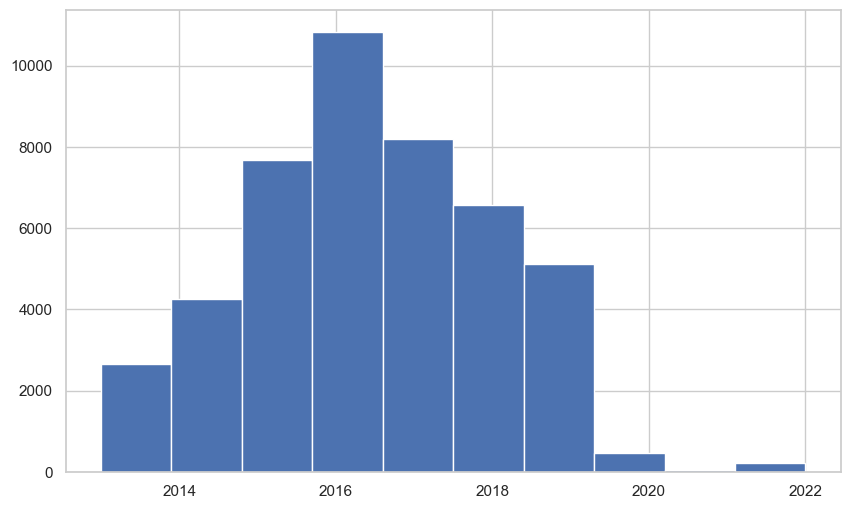

In [45]:
plt.hist(df['visityear'])
plt.show()

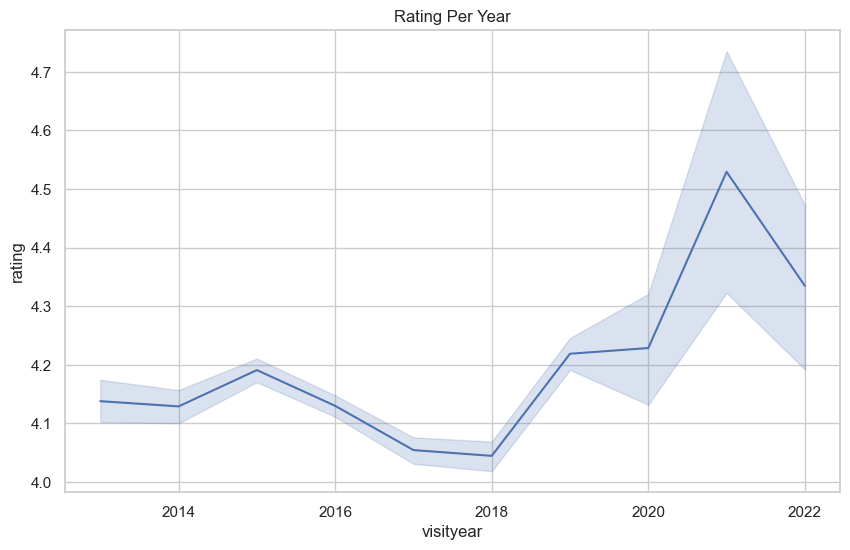

In [46]:
plt.Figure(figsize=(8,5))
sns.lineplot(data=df, x='visityear', y='rating')
plt.title('Rating Per Year')
plt.grid(True)
plt.show()

In [75]:
# sns.scatterplot(data =df, x="visit_year", y = "visit_month")
# plt.show()

In [76]:
# sns.countplot(data= df, x="visit_mode")
# plt.show()

In [74]:
# plt.figure(figsize=(9, 5))
# sns.barplot(data=df, x='continent' , y='visit_month')
# plt.show()

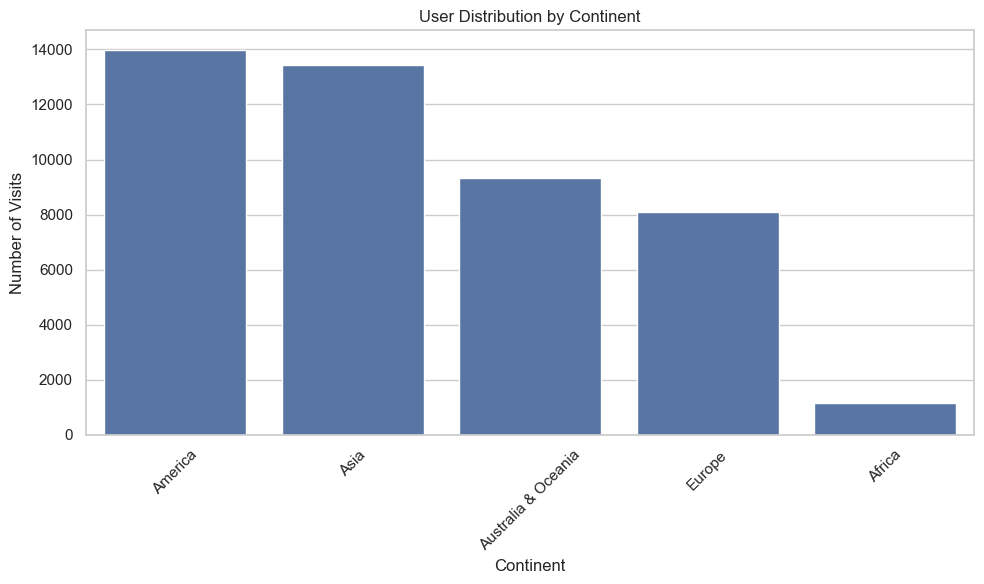

In [47]:
sns.countplot(data=df, x='continent', order=df['continent'].value_counts().index)
plt.title('User Distribution by Continent')
plt.xlabel('Continent')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


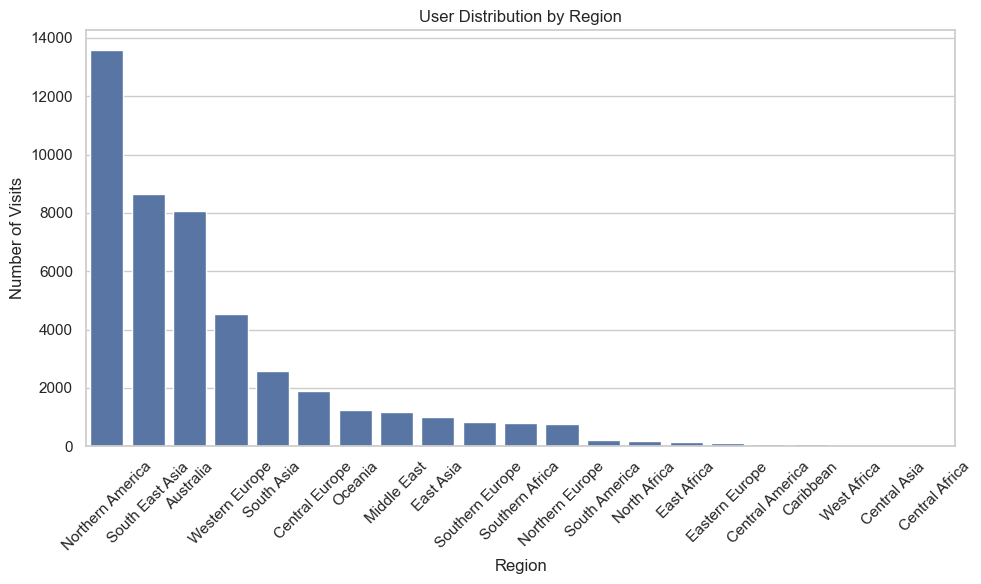

In [48]:
sns.countplot(data=df, x='region', order=df['region'].value_counts().index)
plt.title('User Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



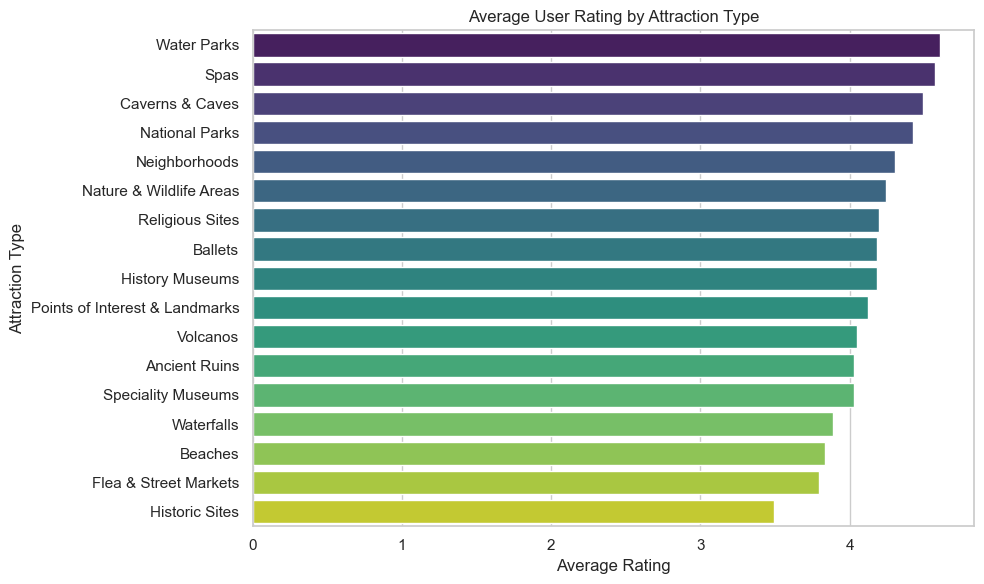

In [49]:
avg_rating_df = df.groupby('attractiontype', as_index=False)['rating'].mean().sort_values(by='rating', ascending=False)

sns.barplot(
    data=avg_rating_df,
    y='attractiontype',
    x='rating',
    hue='attractiontype',
    palette='viridis',
    dodge=False,
    legend=False
)
plt.title('Average User Rating by Attraction Type')
plt.xlabel('Average Rating')
plt.ylabel('Attraction Type')
plt.tight_layout()
plt.show()

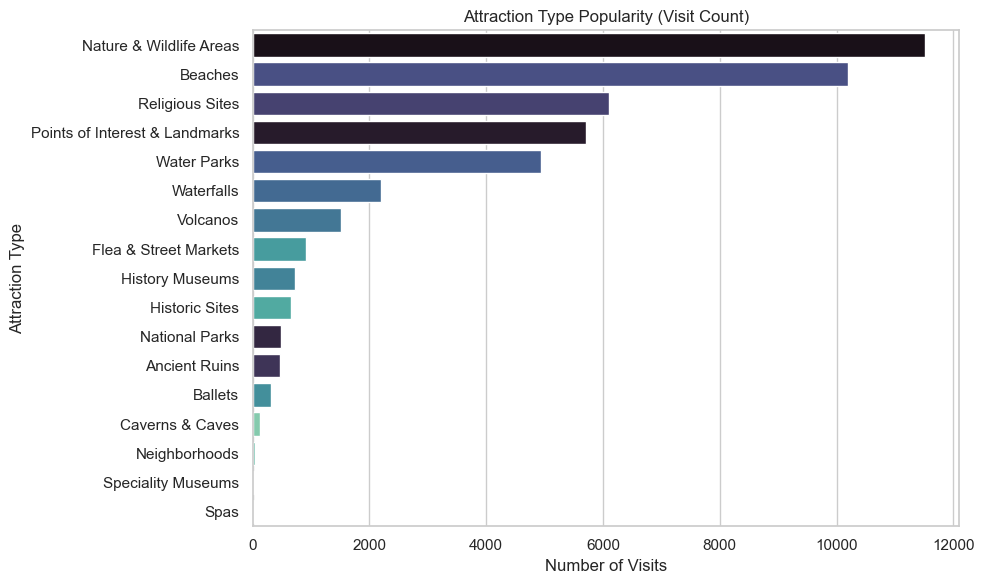

In [50]:
sns.countplot(data=df, y='attractiontype', order=df['attractiontype'].value_counts().index, palette='mako',hue='attractiontype', dodge=False,legend=False)
plt.title('Attraction Type Popularity (Visit Count)')
plt.xlabel('Number of Visits')
plt.ylabel('Attraction Type')
plt.tight_layout()
plt.show()


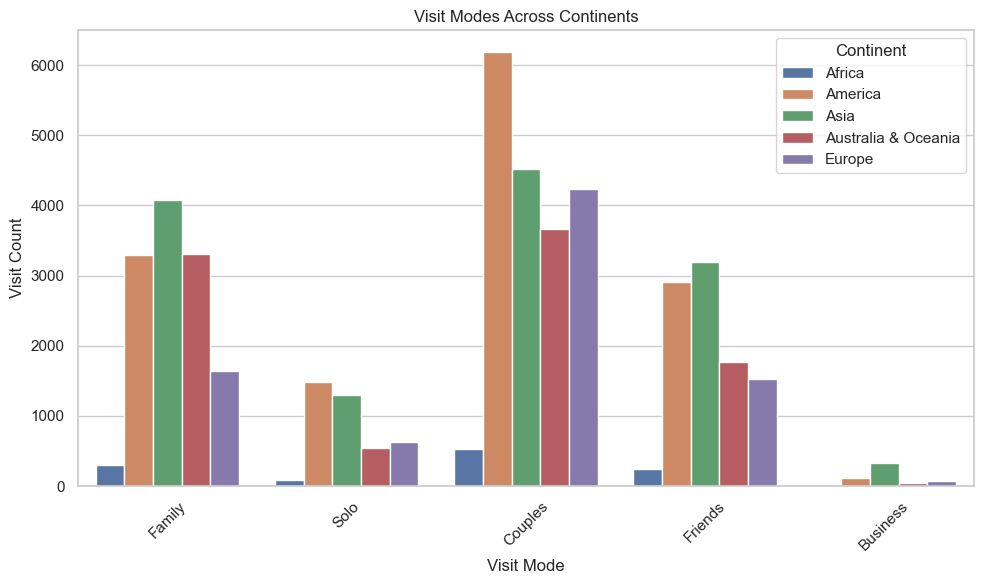

In [51]:
sns.countplot(data=df, x='visitmode', hue='continent')
plt.title('Visit Modes Across Continents')
plt.xlabel('Visit Mode')
plt.ylabel('Visit Count')
plt.xticks(rotation=45)
plt.legend(title='Continent')
plt.tight_layout()
plt.show()


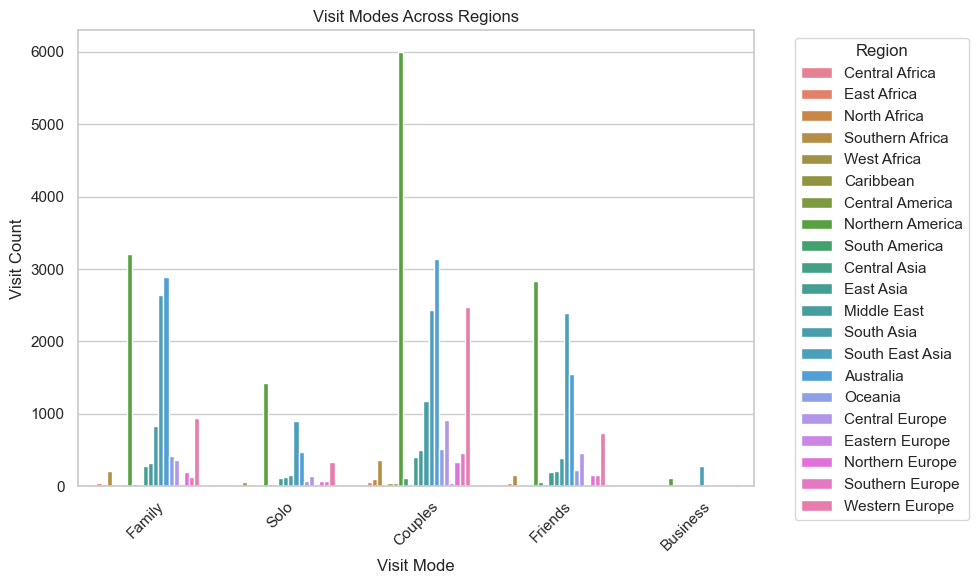

In [52]:
sns.countplot(data=df, x='visitmode', hue='region')
plt.title('Visit Modes Across Regions')
plt.xlabel('Visit Mode')
plt.ylabel('Visit Count')
plt.xticks(rotation=45)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


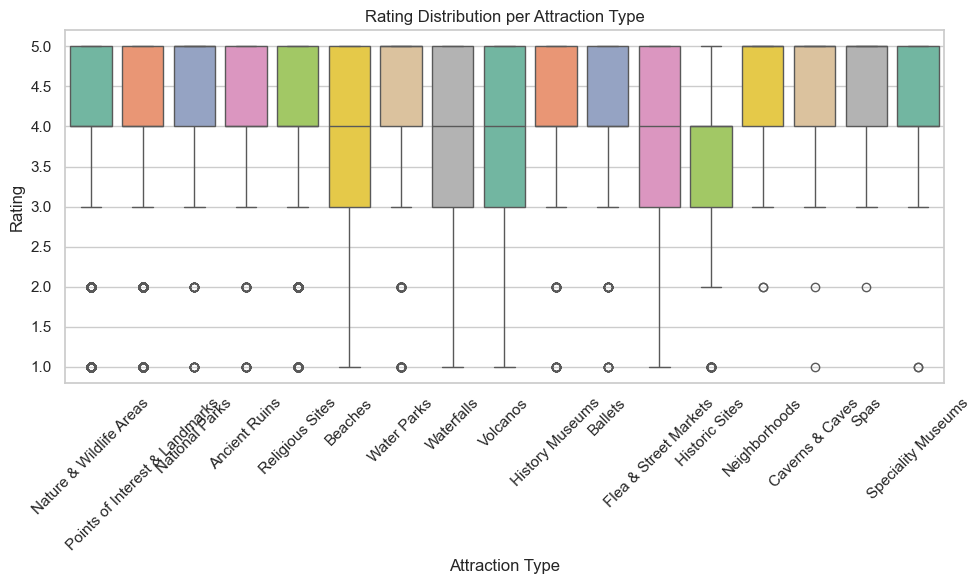

In [53]:
sns.boxplot(data=df, x='attractiontype', y='rating', palette='Set2', hue='attractiontype', dodge=False,legend=False)
plt.title('Rating Distribution per Attraction Type')
plt.xlabel('Attraction Type')
plt.ylabel('Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


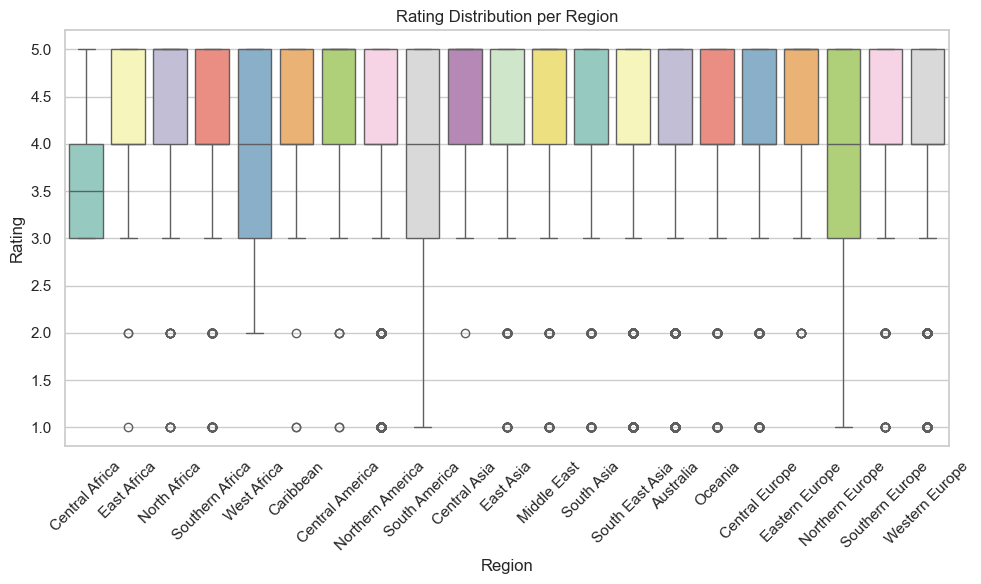

In [54]:
sns.boxplot(data=df, x='region', y='rating', palette='Set3', hue='region', dodge=False,legend=False)
plt.title('Rating Distribution per Region')
plt.xlabel('Region')
plt.ylabel('Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


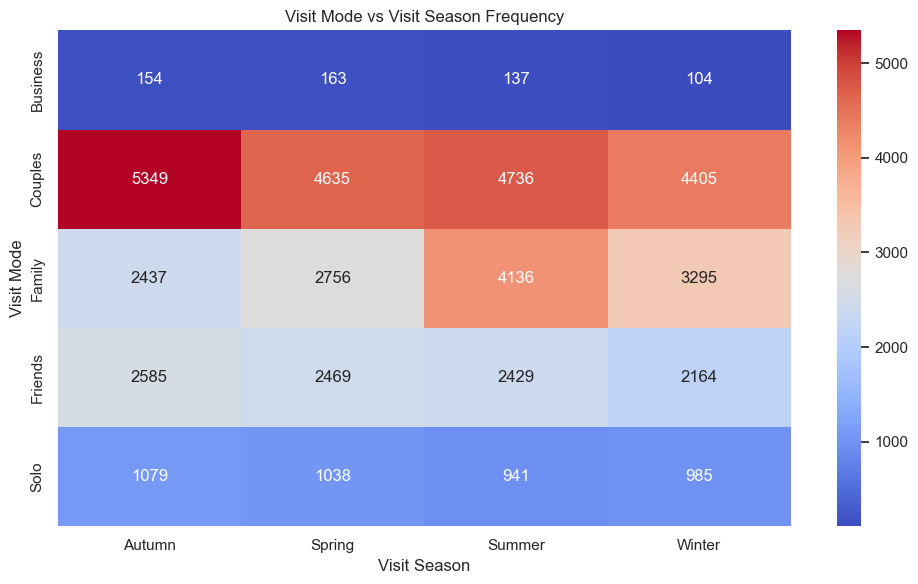

In [55]:
pivot = df.pivot_table(index='visitmode', columns='visit_season', values='rating', aggfunc='count', fill_value=0)

sns.heatmap(pivot, annot=True, fmt='d', cmap='coolwarm')
plt.title('Visit Mode vs Visit Season Frequency')
plt.xlabel('Visit Season')
plt.ylabel('Visit Mode')
plt.tight_layout()
plt.show()


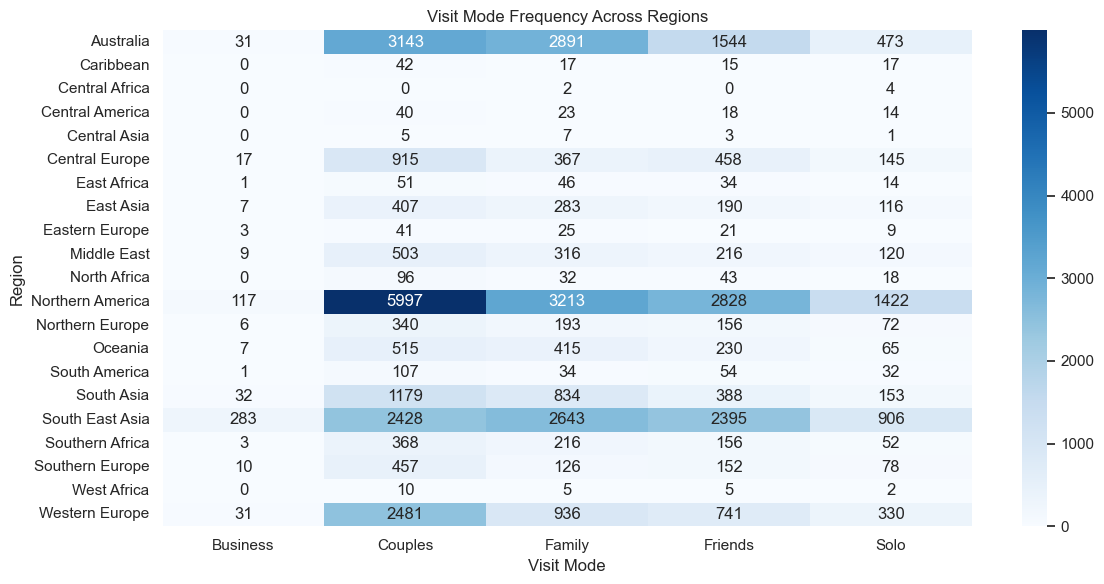

In [56]:
visit_region_pivot = df.pivot_table(index='region', columns='visitmode', values='rating', aggfunc='count', fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(visit_region_pivot, annot=True, fmt='d', cmap='Blues')
plt.title('Visit Mode Frequency Across Regions')
plt.ylabel('Region')
plt.xlabel('Visit Mode')
plt.tight_layout()
plt.show()

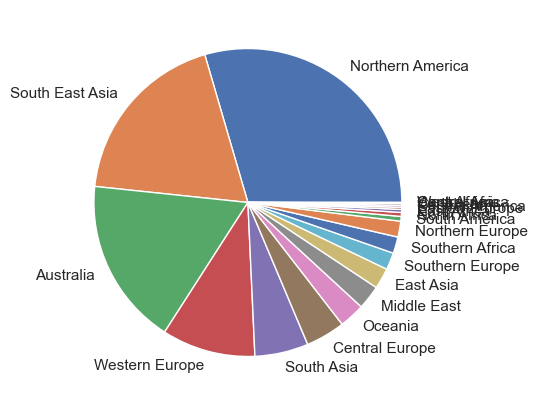

In [57]:
region_count = df['region'].value_counts()
plt.figure(figsize=(8, 5)) 
plt.pie(region_count,labels=region_count.index)
plt.show()

Regression

In [58]:
target = 'rating'  

In [59]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

In [60]:
features = [
    'visityear', 'visitmonth', 'visit_mode_encoded',
    'visit_season_encoded', 'attraction_type_encoded',
    'continent_encoded', 'region_encoded', 'country_encoded', 'city_encoded'
]

X = df[features]
y = df['rating']  


In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Linear Regression RMSE:", root_mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression RMSE: 0.981076012957631
R2 Score: 0.02975707571584152


In [63]:
# predictions for regression -Rating

In [65]:
new_data = pd.DataFrame([{
    'visityear': 2040,
    'visitmonth': 9,
    'visit_mode_encoded': 1,              
    'visit_season_encoded': 3,             
    'attraction_type_encoded': 8 ,         
    'continent_encoded': 3,
    'region_encoded': 16,
    'country_encoded': 7,
    'city_encoded': 831       
}])

In [66]:
predicted_rating = lr.predict(new_data)
print("Predicted Rating:", predicted_rating[0])

Predicted Rating: 4.153978479792062


Classification

In [67]:
features = [
    'visityear', 'visitmonth',
    'attraction_type_encoded',
    'continent_encoded', 'country_encoded', 'city_encoded', 'region_encoded',
    'visit_season_encoded'
]

target = 'visit_mode_encoded'


In [68]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[  10   35   31   24    9]
 [  25 2174  816  570  204]
 [  12 1017  986  422  104]
 [  26  915  445  450  114]
 [  10  392  154  145  110]]
              precision    recall  f1-score   support

           1       0.12      0.09      0.10       109
           2       0.48      0.57      0.52      3789
           3       0.41      0.39      0.40      2541
           4       0.28      0.23      0.25      1950
           5       0.20      0.14      0.16       811

    accuracy                           0.41      9200
   macro avg       0.30      0.28      0.29      9200
weighted avg       0.39      0.41      0.39      9200



In [69]:
new_input_dict = {
    'visityear': 2028,
    'visitmonth': 8,
    'attraction_type_encoded': 10,
    'continent_encoded': 1,
    'country_encoded': 7,
    'city_encoded': 991,
    'region_encoded': 1,
    'visit_season_encoded': 1
}

new_input_df = pd.DataFrame([new_input_dict])[features]

predicted_class = clf.predict(new_input_df)[0]
print("Predicted Visit Mode Encoded:", predicted_class)

visit_mode_reverse_map = {1: 'Business', 2: 'Couples', 3: 'Family', 4: 'Friends'}
print("Predicted Visit Mode:", visit_mode_reverse_map[predicted_class])

Predicted Visit Mode Encoded: 2
Predicted Visit Mode: Couples


Reccomendation

In [70]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

df['user'] = df['continent'] + '_' + df['region'] + '_' + df['visitmode']

user_item_matrix = df.pivot_table(index='user', columns='attraction', values='rating').fillna(0)

In [71]:
user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

In [73]:
def recommend_collaborative(target_user, top_n=3):
    if target_user not in user_item_matrix.index:
        raise ValueError(f"User '{target_user}' not found in the dataset.")
    
    # Get similar users
    sim_users = user_similarity_df[target_user].drop(target_user).sort_values(ascending=False)

    # Only keep users present in the user_item_matrix
    sim_users = sim_users[sim_users.index.isin(user_item_matrix.index)]
    
    # Align indices
    aligned_users = user_item_matrix.loc[sim_users.index]

    # Weighted sum of ratings
    weighted_ratings = aligned_users.T.dot(sim_users)
    summed_weights = sim_users.sum()
    
    if summed_weights == 0:
        raise ValueError("No similar users found to make recommendations.")
    
    recommendations = weighted_ratings / summed_weights

    # Remove already rated attractions
    already_rated = user_item_matrix.loc[target_user]
    recommendations = recommendations[already_rated == 0]

    return recommendations.sort_values(ascending=False).head(top_n)


In [74]:
recommend_collaborative("Asia_South Asia_Friends")

attraction
Malioboro Road       1.806419
Yogyakarta Palace    1.579950
Sewu Temple          1.387270
dtype: float64

Creating a table and inserting data in the database

In [75]:
df.head()

,cityname,country,region,continent,visityear,visitmonth,visitmode,rating,attraction,attractionaddress,...,attraction_type_encoded,continent_encoded,country_encoded,city_encoded,region_encoded,rating_scaled,visit_season,visit_season_encoded,month_name,user
0,Douala,Cameroon,Central Africa,Africa,2018,7,Family,3,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",...,9,1,26,1294,3,0.50,Summer,3,July,Africa_Central Africa_Family
1,Douala,Cameroon,Central Africa,Africa,2018,7,Family,4,Tegalalang Rice Terrace,"Jalan Raya Ceking, Tegalalang 80517 Indonesia",...,11,1,26,1294,3,0.75,Summer,3,July,Africa_Central Africa_Family
2,N'Djamena,Chad,Central Africa,Africa,2017,8,Solo,3,Bromo Tengger Semeru National Park,"Asrikaton - Pakis, Malang 65100 Indonesia",...,8,1,29,3198,3,0.50,Summer,3,August,Africa_Central Africa_Solo
3,Kigali,Rwanda,Central Africa,Africa,2017,12,Solo,4,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",...,9,1,114,2341,3,0.75,Winter,4,December,Africa_Central Africa_Solo
4,Kigali,Rwanda,Central Africa,Africa,2016,3,Solo,5,Sewu Temple,Yogyakarta,...,1,1,114,2341,3,1.00,Spring,2,March,Africa_Central Africa_Solo


In [76]:
import pymysql
import mysql.connector
from mysql.connector import Error

connection = pymysql.connect(
        host='localhost',
        user='root',
        password='Test@123',
        database='Tourism',
        charset='utf8mb4',
        cursorclass=pymysql.cursors.DictCursor
    )


cursor = connection.cursor()
create_table_query ="""
        CREATE TABLE attraction_visits (
                    id INT AUTO_INCREMENT PRIMARY KEY,
                    visit_year INT,
                    visit_month INT,
                    rating INT,
                    continent VARCHAR(100),
                    region VARCHAR(100),
                    country VARCHAR(100),
                    city VARCHAR(100),
                    visit_mode VARCHAR(50),
                    attraction VARCHAR(255),
                    attraction_address TEXT,
                    attraction_type VARCHAR(100),
                    visit_season VARCHAR(50),
                    month_name VARCHAR(50),
                    visit_mode_encoded INT,
                    attraction_type_encoded INT,
                    continent_encoded INT,
                    country_encoded INT,
                    city_encoded INT,
                    region_encoded INT,
                    rating_scaled FLOAT,
                    visit_season_encoded INT
                )
"""
cursor.execute(create_table_query)


insert_query ='''
        INSERT INTO attraction_visits (
                visit_year, visit_month, rating, continent, region, country, city, visit_mode,
                attraction, attraction_address, attraction_type,visit_season, month_name, visit_mode_encoded,
                attraction_type_encoded, continent_encoded, country_encoded, city_encoded,
                region_encoded, rating_scaled, visit_season_encoded
            ) VALUES (
               %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s,
               %s, %s, %s, %s, %s, %s, %s, %s, %s)
'''


data_to_insert = df[[
                'visityear', 'visitmonth', 'rating', 'continent', 'region', 'country', 'cityname', 'visitmode',
                'attraction', 'attractionaddress', 'attractiontype','visit_season', 'month_name','visit_mode_encoded',
                'attraction_type_encoded', 'continent_encoded', 'country_encoded', 'city_encoded',
                'region_encoded', 'rating_scaled', 'visit_season_encoded'
]].values.tolist()


cursor.executemany(insert_query, data_to_insert)
connection.commit()

In [77]:
connection.close()